In [198]:
from qiskit.visualization import plot_histogram
from qiskit_experiments.framework import ParallelExperiment
from qiskit_experiments.library import StateTomography

In [1]:
from pathlib import Path
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'quantum_circuits').is_dir():
        _QC_DIR = _p / 'quantum_circuits'
        break
else:
    _QC_DIR = _here / 'quantum_circuits'

from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_ibm_runtime import Session, Batch, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

with open(_QC_DIR / 'Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [2]:
Operator(Xgate3).draw('latex')

<IPython.core.display.Latex object>

In [13]:
Xgate3.draw('latex_source')

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{{$\\mathrm{global\\,phase:\\,} \\mathrm{\\frac{7\\pi}{4}}$}\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\qw & \\qswap & \\ctrl{1} & \\dstick{\\hspace{2.0em}\\mathrm{ZZ}\\,(\\mathrm{\\frac{\\pi}{2}})} \\qw & \\qw & \\qw & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{-\\pi}{2}})} & \\gate{\\mathrm{R_Y}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\pi})} & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\gate{\\mathrm{R_Y}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\qswap \\qwx[-1] & \\control \\qw & \\qw & \\qw & \\qw & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{2}})} & \\qw & \\qw & \\qw & \\qw\\\\\n\\\\ }}\n\\end{document}'

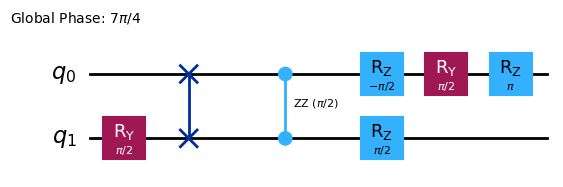

In [14]:
Xgate3.draw('mpl')

In [3]:
Operator(Zgate3).draw('latex')

<IPython.core.display.Latex object>

In [15]:
Zgate3.draw('latex_source')

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{\\pi}{12}})} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{7\\pi}{12}})} & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{-\\pi}{12}})} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{\\frac{-7\\pi}{12}})} & \\qw & \\qw\\\\\n\\\\ }}\n\\end{document}'

In [16]:
Statevector(Fgate3).draw('latex')

<IPython.core.display.Latex object>

In [5]:
omega = np.exp(2j * np.pi / 3)

In [7]:
omega

np.complex128(-0.4999999999999998+0.8660254037844387j)

In [8]:
from pathlib import Path
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'quantum_circuits').is_dir():
        _QC_DIR = _p / 'quantum_circuits'
        break
else:
    _QC_DIR = _here / 'quantum_circuits'

with open(_QC_DIR / 'Fgate3.qpy', 'rb') as fd:
    Fgate3 = qpy.load(fd)[0]

In [20]:
(np.sqrt(3) * Operator(Fgate3)).draw('latex')

<IPython.core.display.Latex object>

In [10]:
Operator(FDAGgate3).draw('latex')

<IPython.core.display.Latex object>

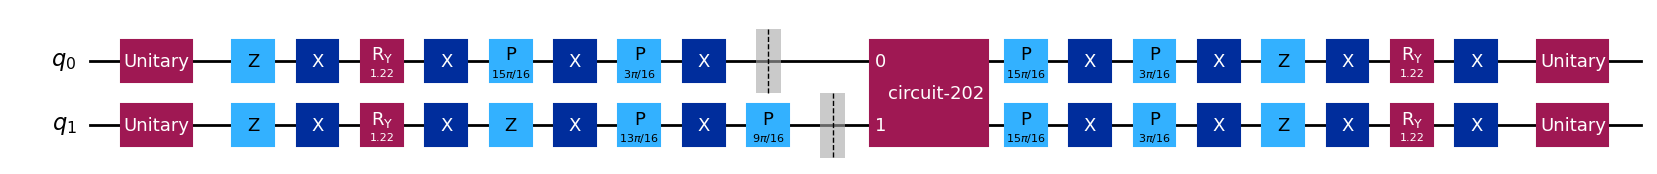

In [25]:
Fgate3.decompose().draw('mpl')

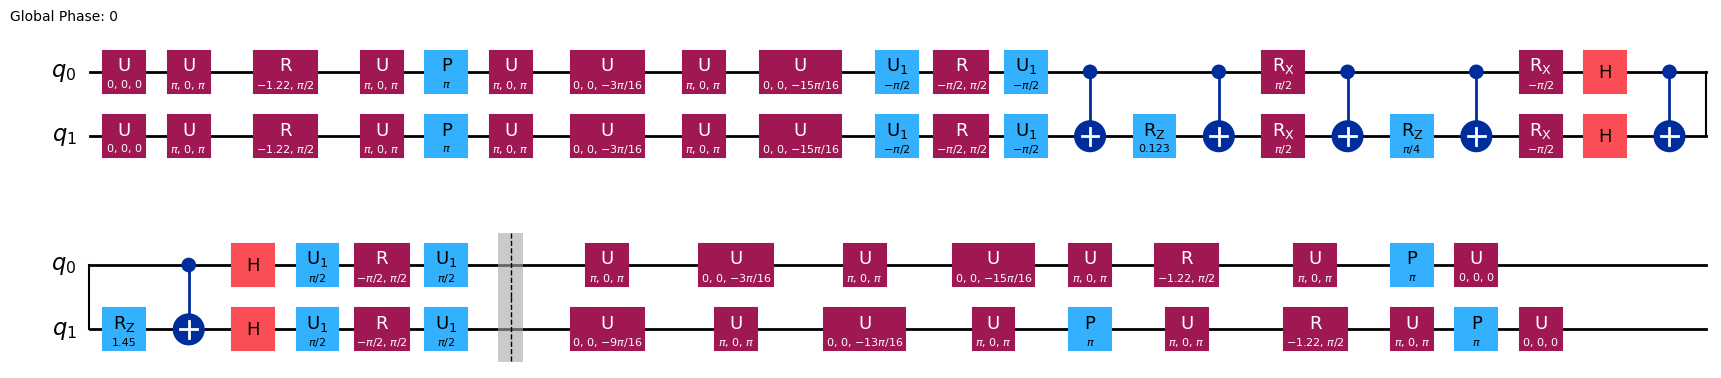

In [30]:
FDAGgate3.decompose().decompose().draw('mpl')

In [32]:
TwoQubitWeylDecomposition(Operator(Fgate3)).circuit().draw("latex_source")

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{{$\\mathrm{global\\,phase:\\,} \\mathrm{\\frac{15\\pi}{8}}$}\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\gate{\\mathrm{R_Z}\\,(\\mathrm{1.24})} & \\gate{\\mathrm{R_Y}\\,(\\mathrm{2.297})} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{-0.4777})} & \\multigate{1}{\\mathrm{R_{XX}}\\,(\\mathrm{-1.448})}_<<<{0} & \\multigate{1}{\\mathrm{R_{YY}}\\,(\\mathrm{\\frac{-\\pi}{4}})}_<<<{0} & \\ctrl{1} & \\dstick{\\hspace{2.0em}\\mathrm{ZZ}\\,(\\mathrm{-0.1233})} \\qw & \\qw & \\qw & \\gate{\\mathrm{R_Z}\\,(\\mathrm{2.664})} & \\gate{\\mathrm{R_Y}\\,(\\mathrm{2.297})} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{-1.902})} & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\gate{\\mathrm{R_Z}\\,(\\mathrm{1.24})} & \\gate{\\mathrm{R_Y}\\,(\\mathrm{2.297})} & \\gate{\\mathrm{R_Z}\\,(\\mathrm{-0.4777})} & \\gho

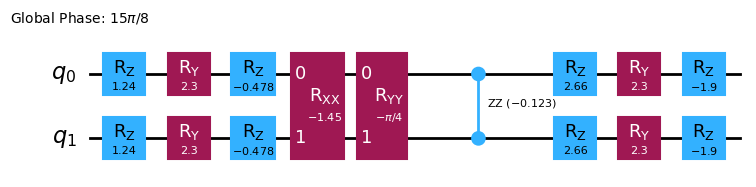

In [34]:
TwoQubitWeylDecomposition(Operator(Fgate3)).circuit().draw("mpl")

In [21]:
from pathlib import Path
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'quantum_circuits').is_dir():
        _QC_DIR = _p / 'quantum_circuits'
        break
else:
    _QC_DIR = _here / 'quantum_circuits'

with open(_QC_DIR / 'CZgate3.qpy', 'rb') as fd:
    CZgate3 = qpy.load(fd)[0]

In [35]:
CZgate3.draw('latex_source')

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{\n\\Qcircuit @C=1.0em @R=0.8em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\ctrl{2} & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{3} & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\qw & \\dstick{\\hspace{2.0em}\\mathrm{P}\\,(\\mathrm{\\frac{2\\pi}{3}})} \\qw & \\qw & \\qw & \\ctrl{2} & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\ctrl{1} & \\dstick{\\hspace{2.0em}\\mathrm{P}\\,(\\mathrm{\\frac{-2\\pi}{3}})} \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{2} :  } & \\lstick{{q}_{2} :  } & \\control \\qw & \\qw & \\qw & \\qw & \\qw & \\dstick{\\hspace{2.0em}\\mathrm{P}\\,(\\mathrm{\\frac{2\\pi}{3}})} \\qw & \\qw & \\qw & \\qw & \\dstick{\\hspace{2.0em}\\mathrm{P}\\,(\\mathrm{\\frac{-2\\pi}{3}})} \\qw & \\qw & \\qw & \\control \

In [23]:
Operator(CZgate3).draw('latex')

<IPython.core.display.Latex object>

In [3]:
from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

In [4]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [118]:
from pathlib import Path
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'quantum_circuits').is_dir():
        _QC_DIR = _p / 'quantum_circuits'
        break
else:
    _QC_DIR = _here / 'quantum_circuits'

with open(_QC_DIR / 'Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open(_QC_DIR / 'FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [5]:
qc2, g2 = create_ame_circuit(2, 3)

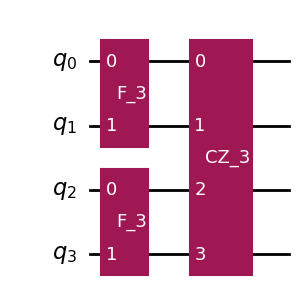

In [6]:
qc2.draw("mpl")

In [180]:
ghzqc, g3 = create_ame_circuit(3, 3)
ghzqc.append(FDAGgate3, [2, 3])
ghzqc.append(FDAGgate3, [4, 5])

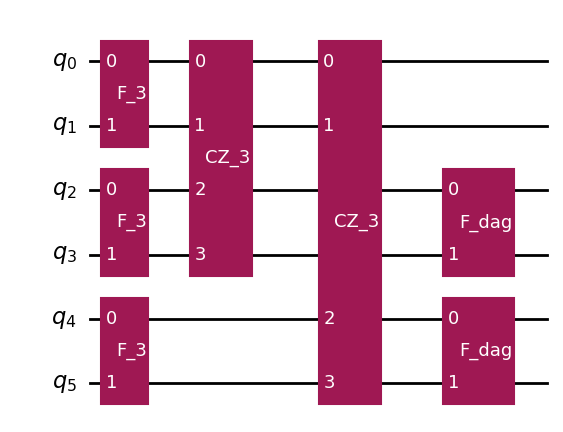

In [181]:
ghzqc.draw("mpl")

In [182]:
Statevector(ghzqc).draw('latex')

<IPython.core.display.Latex object>

In [191]:
Statevector(ghzqc).expectation_value(Operator(Xgate3) ^ Operator(Xgate3) ^ Operator(Xgate3))

np.complex128(1.0000000000000013-6.661338147750947e-16j)

In [7]:
def Ry01(theta):
    mtx = np.array([
        [np.cos(theta/2), -np.sin(theta/2), 0, 0],
        [np.sin(theta/2), np.cos(theta/2), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

def Ry02(theta):
    mtx = np.array([
        [np.cos(theta/2),   0, -np.sin(theta/2),    0],
        [0,                 1, 0,                   0],
        [np.sin(theta/2),   0, np.cos(theta/2),     0],
        [0,                 0, 0,                   1]
    ])
    return Operator(mtx)

def Ry12(theta):
    mtx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta/2), -np.sin(theta/2), 0],
        [0, np.sin(theta/2), np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

In [22]:
def Rx01(theta):
    mtx = np.array([
        [np.cos(theta/2), -1j*np.sin(theta/2), 0, 0],
        [-1j*np.sin(theta/2), np.cos(theta/2), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return mtx

def Rx02(theta):
    mtx = np.array([
        [np.cos(theta/2), 0, -1j*np.sin(theta/2), 0],
        [0, 1, 0, 0],
        [-1j*np.sin(theta/2), 0, np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return mtx

def Rx12(theta):
    mtx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta/2), -1j*np.sin(theta/2), 0],
        [0, -1j*np.sin(theta/2), np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return mtx

In [52]:
def Hx01():
    rx0 = Operator(Rx01(-np.pi))
    rx1 = Operator(Ry01(np.pi / 2))
    qc = rx0 @ rx1
    return qc

In [53]:
def Hx02():
    ry0 = Operator(Ry01(np.pi))
    rx0 = Operator(Rx12(np.pi))
    ry1 = Operator(Ry12(-np.pi / 2))
    ry2 = Operator(Ry01(-np.pi))

    qc = ry0 @ rx0 @ ry1 @ ry2
    return qc

In [54]:
def Hx12():
    ry0 = Operator(Ry12(-np.pi/2))
    rx0 = Operator(Rx12(-np.pi))

    return ry0 @ rx0

In [55]:
def Hy01():
    rx0 = Operator(Rx01(-np.pi / 2))
    rx1 = Operator(Ry01(np.pi))
    qc = rx0 @ rx1
    return qc

In [56]:
def Hy02():
    ry0 = Operator(Ry12(np.pi))
    rx0 = Operator(Rx01(-np.pi/2))
    ry1 = Operator(Ry01(np.pi))
    ry2 = Operator(Ry12(-np.pi))

    qc = ry0 @ rx0 @ ry1 @ ry2
    return qc

In [57]:
def Hy12():
    ry0 = Operator(Rx12(-np.pi/2))
    rx0 = Operator(Ry12(np.pi))

    return ry0 @ rx0

In [208]:
def x01():
    mtx = np.array([
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [209]:
def x02():
    mtx = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [210]:
def x12():
    mtx = np.array([
        [0, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [211]:
def y01():
    mtx = np.array([
        [0, -1j, 0, 0],
        [1j, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [212]:
def y02():
    mtx = np.array([
        [0, 0, -1j, 0],
        [0, 0, 0, 0],
        [1j, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [213]:
def y12():
    mtx = np.array([
        [0, 0, 0, 0],
        [0, 0, -1j, 0],
        [0, 1j, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [215]:
hdict = {
    "01x": x01(),
    "02x": x02(),
    "12x": x12(),
    "01y": y01(),
    "02y": y02(),
    "12y": y12(),
}

Robie 000 z 000, 111 z 111, 222 z 222, 000 z 111, 000 z 222, 111 z 222, czyli mam 6 par

In [216]:
def reindex(n, m):
    keyx = f"{n}{m}x"
    keyy = f"{n}{m}y"

    oplist = [hdict[keyx] ^ hdict[keyx] ^ hdict[keyx], hdict[keyy] ^ hdict[keyy] ^ hdict[keyx], hdict[keyy] ^ hdict[keyx] ^ hdict[keyy], hdict[keyx] ^ hdict[keyy] ^ hdict[keyy]]

    return oplist

In [217]:
op01 = reindex(0, 1)
op02 = reindex(0, 2)
op12 = reindex(1, 2)

In [219]:
aer = AerEstimator()

In [221]:
oppauli1 = [SparsePauliOp.from_operator(op) for op in op01]
oppauli2 = [SparsePauliOp.from_operator(op) for op in op02]
oppauli3 = [SparsePauliOp.from_operator(op) for op in op12]

In [224]:
pub = (ghzqc.decompose().decompose().decompose(), [oppauli1, oppauli2, oppauli3])

In [188]:
pubim = (ghzqc.decompose().decompose().decompose(), [op01im, op02im, op12im])

In [225]:
job = aer.run([pub])
result = job.result()

In [226]:
result[0].data.evs

array([[ 0.66666667, -0.66666667, -0.66666667, -0.66666667],
       [ 0.66666667, -0.66666667, -0.66666667, -0.66666667],
       [ 0.66666667, -0.66666667, -0.66666667, -0.66666667]])

In [156]:
result[0].data.evs[2][3]

np.float64(0.3333333333333354)

In [227]:
re0sum = 1/8 * (result[0].data.evs[0][0] - result[0].data.evs[0][1] - result[0].data.evs[0][2] - result[0].data.evs[0][3])
re1sum = 1/8 * (result[0].data.evs[1][0] - result[0].data.evs[1][1] - result[0].data.evs[1][2] - result[0].data.evs[1][3])
re2sum = 1/8 * (result[0].data.evs[2][0] - result[0].data.evs[2][1] - result[0].data.evs[2][2] - result[0].data.evs[2][3])

In [158]:
re0sum

np.float64(-0.08333333333333376)

In [163]:
jobim = aer.run([pubim])
resultim = jobim.result()

In [189]:
resultim[0].data.evs

array([[-0.01001274, -0.01001274, -0.01001274, -0.01001274],
       [-0.005179  , -0.005179  , -0.005179  , -0.005179  ],
       [ 0.00483374,  0.00483374,  0.00483374,  0.00483374]])

In [228]:
aersam = AerSampler()

In [229]:
ghzqc.measure_all()

In [230]:
job = aersam.run([(ghzqc.decompose().decompose().decompose())])

In [231]:
result = job.result()

In [232]:
from qiskit.visualization import plot_histogram

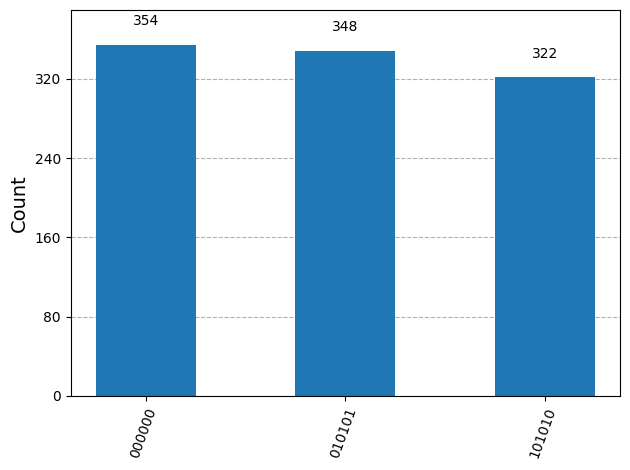

In [233]:
plot_histogram(result[0].data.meas.get_counts())

In [234]:
res0 = result[0].data.meas.get_counts()["000000"]
res1 = result[0].data.meas.get_counts()["010101"]
res2 = result[0].data.meas.get_counts()["101010"]

In [235]:
ntot = res0 + res1 + res2

In [236]:
prob0 = res0 / ntot
prob1 = res1 / ntot
prob2 = res2 / ntot

In [237]:
fid = 1/3 * (prob0 + prob1 + prob2 + 2 * (re0sum + re1sum + re2sum))

In [238]:
fid

np.float64(1.000000000000004)

In [239]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, Batch

In [316]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-11-21 02:17:57,700: Default instance not set. Searching all available instances.


In [317]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [318]:
ghz_isa = pm.run(ghzqc)

In [319]:
oppauli1_isa = [SparsePauliOp.from_operator(op).apply_layout(layout=ghz_isa.layout) for op in op01]
oppauli2_isa = [SparsePauliOp.from_operator(op).apply_layout(layout=ghz_isa.layout) for op in op02]
oppauli3_isa = [SparsePauliOp.from_operator(op).apply_layout(layout=ghz_isa.layout) for op in op12]

In [320]:
pub_isa = (ghz_isa, [oppauli1_isa, oppauli2_isa, oppauli3_isa])

In [321]:
est = AerEstimator()

In [322]:
job = aer.run([pub_isa])
result = job.result()

In [323]:
re0sum = 1/8 * (result[0].data.evs[0][0] - result[0].data.evs[0][1] - result[0].data.evs[0][2] - result[0].data.evs[0][3])
re1sum = 1/8 * (result[0].data.evs[1][0] - result[0].data.evs[1][1] - result[0].data.evs[1][2] - result[0].data.evs[1][3])
re2sum = 1/8 * (result[0].data.evs[2][0] - result[0].data.evs[2][1] - result[0].data.evs[2][2] - result[0].data.evs[2][3])

In [324]:
aersam = AerSampler()

In [325]:
jobsam = aersam.run([(ghz_isa)])

In [326]:
resultsam = jobsam.result()

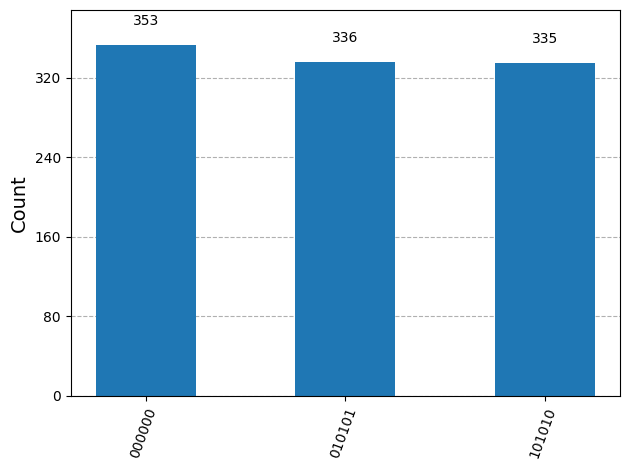

In [327]:
plot_histogram(resultsam[0].data.meas.get_counts())

In [337]:
with Batch(backend=backend) as batch:
    est_ibm = Estimator()
    est_ibm.options.default_shots = 500
    #est_ibm.options.resilience_level = 2
    job_ibm = est_ibm.run([pub_isa])

In [330]:
with Batch(backend=backend) as batch:
    sam_ibm = Sampler()
    sam_ibm.options.default_shots = 1024
    jobsam_ibm = sam_ibm.run([(ghz_isa)])

In [343]:
result = job_ibm.result()

re0sum = 1/8 * (result[0].data.evs[0][0] - result[0].data.evs[0][1] - result[0].data.evs[0][2] - result[0].data.evs[0][3])
re1sum = 1/8 * (result[0].data.evs[1][0] - result[0].data.evs[1][1] - result[0].data.evs[1][2] - result[0].data.evs[1][3])
re2sum = 1/8 * (result[0].data.evs[2][0] - result[0].data.evs[2][1] - result[0].data.evs[2][2] - result[0].data.evs[2][3])

resultsam = jobsam_ibm.result()

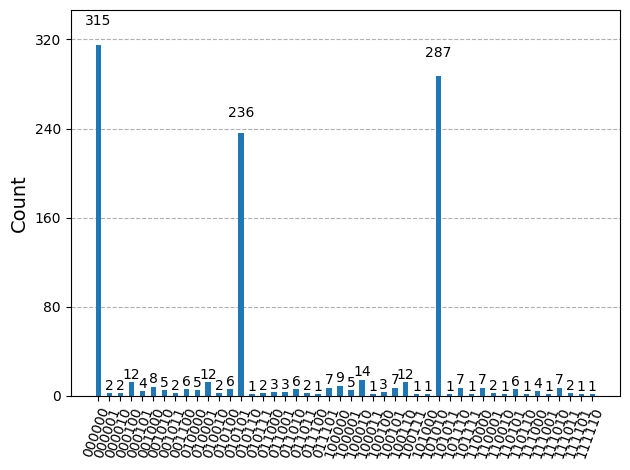

In [311]:
plot_histogram(resultsam[0].data.meas.get_counts())

In [344]:
result = job_ibm.result()

re0sum = 1/8 * (result[0].data.evs[0][0] - result[0].data.evs[0][1] - result[0].data.evs[0][2] - result[0].data.evs[0][3])
re1sum = 1/8 * (result[0].data.evs[1][0] - result[0].data.evs[1][1] - result[0].data.evs[1][2] - result[0].data.evs[1][3])
re2sum = 1/8 * (result[0].data.evs[2][0] - result[0].data.evs[2][1] - result[0].data.evs[2][2] - result[0].data.evs[2][3])

resultsam = jobsam_ibm.result()

res0 = resultsam[0].data.meas.get_counts()["000000"]
res1 = resultsam[0].data.meas.get_counts()["010101"]
res2 = resultsam[0].data.meas.get_counts()["101010"]

ntot = res0 + res1 + res2

prob0 = res0 / ntot
prob1 = res1 / ntot
prob2 = res2 / ntot

fid = 1/3 * (prob0 + prob1 + prob2 + 2 * (re0sum + re1sum + re2sum))

fidelity bez mitygacji

In [315]:
fid

np.float64(0.8587261328878754)

fidelity z mitygacja

In [332]:
fid

np.float64(0.9894031283354796)

In [345]:
s1 = 1/4 * np.sqrt((result[0].data.stds[0][0]**2 + result[0].data.stds[0][1]**2 + result[0].data.stds[0][2]**2 + result[0].data.stds[0][3]**2))
s2 = 1/4 * np.sqrt((result[0].data.stds[1][0]**2 + result[0].data.stds[1][1]**2 + result[0].data.stds[1][2]**2 + result[0].data.stds[1][3]**2))
s3 = 1/4 * np.sqrt((result[0].data.stds[2][0]**2 + result[0].data.stds[2][1]**2 + result[0].data.stds[2][2]**2 + result[0].data.stds[2][3]**2))

In [346]:
var1 = np.sqrt(prob0 * (1 - prob0) / ntot)
var2 = np.sqrt(prob1 * (1 - prob1) / ntot)
var3 = np.sqrt(prob2 * (1 - prob2) / ntot)

In [347]:
stds_tot = 1/3 * np.sqrt(var1**2 + var2**2 + var3**2 + 1/64 * 4 * (s1**2 + s2**2 + s3**2))

stds z mitygacja

In [336]:
stds_tot

np.float64(0.010591192471820473)

stds bez mitygacji

In [348]:
stds_tot

np.float64(0.009471772882176033)